# 🎧 EDA Spotify Tracks 2023 (R)

Autor: José Manuel Sánchez Álvarez  
Centro: IES Rafael Alberti — Curso 2025–2026  

Exploración de datos del dataset *Spotify Tracks 2023* usando **R y tidyverse**.

Este notebook realiza un análisis exploratorio (EDA) para estudiar popularidad, duración, energía, correlaciones y géneros musicales.


## 1️⃣ Preparación del entorno

Se cargan las librerías necesarias y se configuran los gráficos inline.

In [1]:
suppressPackageStartupMessages({
  if (!requireNamespace("tidyverse", quietly = TRUE)) install.packages("tidyverse", repos = "https://cloud.r-project.org")
  if (!requireNamespace("ggcorrplot", quietly = TRUE)) install.packages("ggcorrplot", repos = "https://cloud.r-project.org")
  library(tidyverse)
  library(ggcorrplot)
})
options(repr.plot.width = 7, repr.plot.height = 4)
sessionInfo()


R version 4.5.2 (2025-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Pop!_OS 22.04 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=es_ES.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=es_ES.UTF-8        LC_COLLATE=es_ES.UTF-8    
 [5] LC_MONETARY=es_ES.UTF-8    LC_MESSAGES=es_ES.UTF-8   
 [7] LC_PAPER=es_ES.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=es_ES.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggcorrplot_0.1.4.1 forcats_0.5.1      stringr_1.4.0      dplyr_1.0.8       
 [5] purrr_1.2.0        readr_2.1.2        tidyr_1.2.0        tibble_3.1.6      
 [9] ggplot2

## 2️⃣ Carga del dataset

Se intentará descargar automáticamente desde una fuente pública. Si falla, se utilizará un archivo local `spotify_tracks_2023.csv`.

In [4]:
url <- "https://raw.githubusercontent.com/marceloreisjr/datasets/master/spotify_tracks_2023.csv"
spotify <- tryCatch({
  read_csv(url)
}, error = function(e) {
  message("Descarga fallida. Cargando archivo local...")
  read_csv("./Seaborn/spotify-2023_2.csv")
})

glimpse(spotify)
head(spotify)


Descarga fallida. Cargando archivo local...

New names:
• `` -> `...1`
Rows: 114000 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): track_id, artists, album_name, track_name, track_genre
dbl (15): ...1, popularity, duration_ms, danceability, energy, key, loudness...
lgl  (1): explicit

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 114,000
Columns: 21
$ ...1             <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,…
$ track_id         <chr> "5SuOikwiRyPMVoIQDJUgSV", "4qPNDBW1i3p13qLCt0Ki3A", "…
$ artists          <chr> "Gen Hoshino", "Ben Woodward", "Ingrid Michaelson;ZAY…
$ album_name       <chr> "Comedy", "Ghost (Acoustic)", "To Begin Again", "Craz…
$ track_name       <chr> "Comedy", "Ghost - Acoustic", "To Begin Again", "Can'…
$ popularity       <dbl> 73, 55, 57, 71, 82, 58, 74, 80, 74, 56, 74, 69, 52, 6…
$ duration_ms      <dbl> 230666, 149610, 210826, 201933, 198853, 214240, 22940…
$ explicit         <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALS…
$ danceability     <dbl> 0.676, 0.420, 0.438, 0.266, 0.618, 0.688, 0.407, 0.70…
$ energy           <dbl> 0.4610, 0.1660, 0.3590, 0.0596, 0.4430, 0.4810, 0.147…
$ key              <dbl> 1, 1, 0, 0, 2, 6, 2, 11, 0, 1, 8, 4, 7, 3, 2, 4, 2, 1…
$ loudness         <dbl> -6.746, -17.235, -9.734, -18.515, -9.681, -8.807, -8.…
$ mode        

...1,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,⋯,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,FALSE,0.676,0.4610,⋯,-6.746,0,0.1430,0.0322,1.01e-06,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,FALSE,0.420,0.1660,⋯,-17.235,1,0.0763,0.9240,5.56e-06,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,FALSE,0.438,0.3590,⋯,-9.734,1,0.0557,0.2100,0.00e+00,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Soundtrack),Can't Help Falling In Love,71,201933,FALSE,0.266,0.0596,⋯,-18.515,1,0.0363,0.9050,7.07e-05,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,FALSE,0.618,0.4430,⋯,-9.681,1,0.0526,0.4690,0.00e+00,0.0829,0.167,119.949,4,acoustic
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,FALSE,0.688,0.4810,⋯,-8.807,1,0.1050,0.2890,0.00e+00,0.1890,0.666,98.017,4,acoustic


## 3️⃣ Limpieza básica

- Eliminamos columnas irrelevantes (`Unnamed:_0` si existe).
- Quitamos duplicados.
- Comprobamos valores nulos.

In [5]:
if ("Unnamed:_0" %in% colnames(spotify)) {
  spotify <- spotify %>% select(-`Unnamed:_0`)
}

spotify <- spotify %>% distinct()

colSums(is.na(spotify)) %>% sort(decreasing = TRUE)


artists       album_name       track_name             ...1 
               1                1                1                0 
        track_id       popularity      duration_ms         explicit 
               0                0                0                0 
    danceability           energy              key         loudness 
               0                0                0                0 
            mode      speechiness     acousticness instrumentalness 
               0                0                0                0 
        liveness          valence            tempo   time_signature 
               0                0                0                0 
     track_genre 
               0

## 4️⃣ Estadísticas descriptivas

- Popularidad
- Duración (convertida a minutos)
- Valores de energía, valence, danceability, etc.

In [6]:
spotify <- spotify %>% mutate(duration_min = duration_ms / 60000)

summary(select(spotify, popularity, duration_min, danceability, energy, valence, tempo))


   popularity      duration_min     danceability        energy      
 Min.   :  0.00   Min.   : 0.000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.: 17.00   1st Qu.: 2.901   1st Qu.:0.4560   1st Qu.:0.4720  
 Median : 35.00   Median : 3.548   Median :0.5800   Median :0.6850  
 Mean   : 33.24   Mean   : 3.800   Mean   :0.5668   Mean   :0.6414  
 3rd Qu.: 50.00   3rd Qu.: 4.358   3rd Qu.:0.6950   3rd Qu.:0.8540  
 Max.   :100.00   Max.   :87.288   Max.   :0.9850   Max.   :1.0000  
    valence           tempo       
 Min.   :0.0000   Min.   :  0.00  
 1st Qu.:0.2600   1st Qu.: 99.22  
 Median :0.4640   Median :122.02  
 Mean   :0.4741   Mean   :122.15  
 3rd Qu.:0.6830   3rd Qu.:140.07  
 Max.   :0.9950   Max.   :243.37  

## 5️⃣ Visualizaciones básicas

### 5.1 Distribución de popularidad

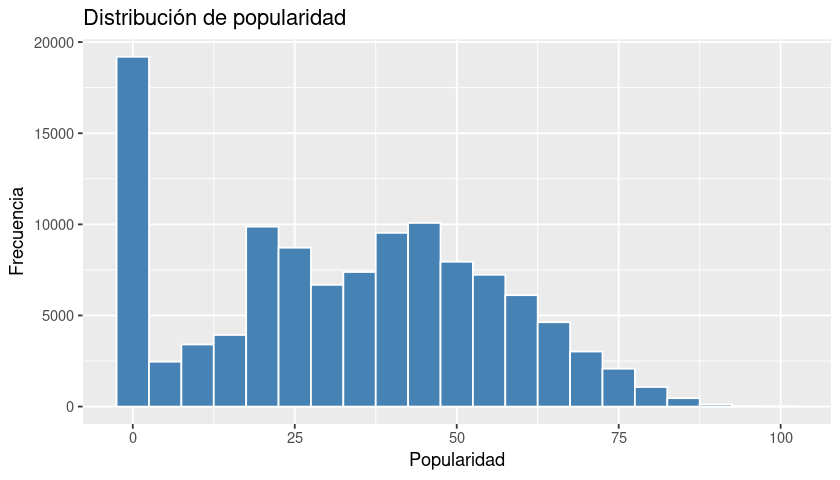

In [7]:
ggplot(spotify, aes(x = popularity)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "white") +
  labs(title = "Distribución de popularidad", x = "Popularidad", y = "Frecuencia")


### 5.2 Duración de canciones (en minutos)

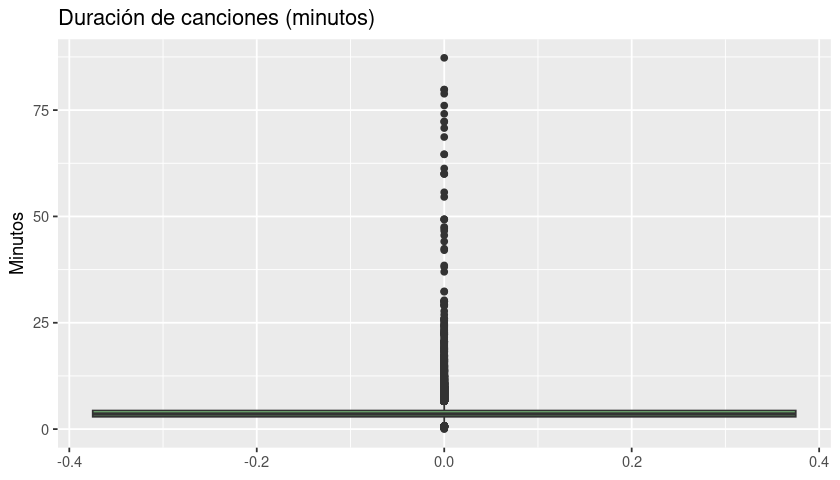

In [8]:
ggplot(spotify, aes(y = duration_min)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Duración de canciones (minutos)", y = "Minutos")


## 6️⃣ Correlaciones entre variables numéricas

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


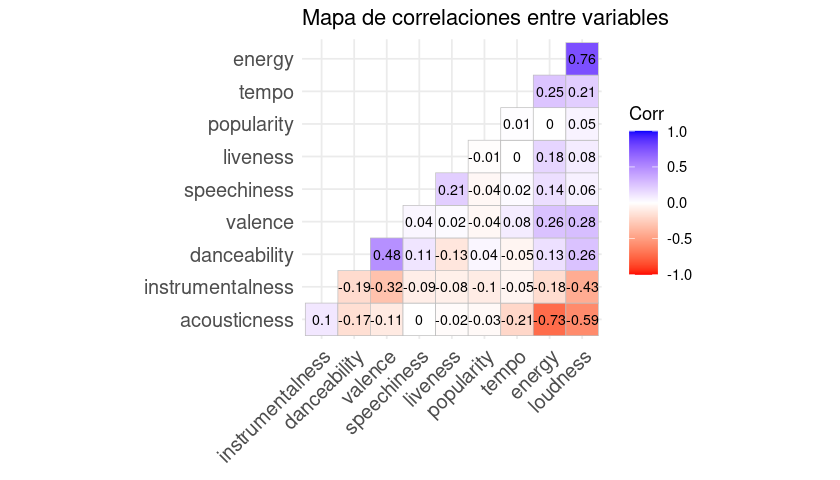

In [9]:
num_cols <- spotify %>% select(popularity, danceability, energy, loudness, speechiness,
                               acousticness, instrumentalness, liveness, valence, tempo)

corr_matrix <- cor(num_cols, use = "complete.obs")
ggcorrplot(corr_matrix, hc.order = TRUE, type = "lower", lab = TRUE, lab_size = 3,
           colors = c("red", "white", "blue"), title = "Mapa de correlaciones entre variables")


## 7️⃣ Popularidad media por género

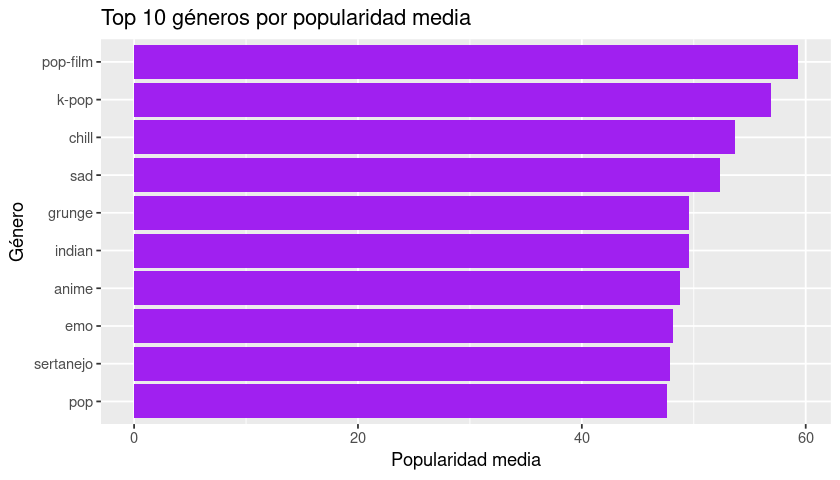

In [10]:
genre_stats <- spotify %>%
  group_by(track_genre) %>%
  summarise(media_pop = mean(popularity, na.rm = TRUE), canciones = n()) %>%
  arrange(desc(media_pop))

top_genres <- head(genre_stats, 10)

ggplot(top_genres, aes(x = reorder(track_genre, media_pop), y = media_pop)) +
  geom_col(fill = "purple") +
  coord_flip() +
  labs(title = "Top 10 géneros por popularidad media", x = "Género", y = "Popularidad media")


## 8️⃣ Top artistas por popularidad media

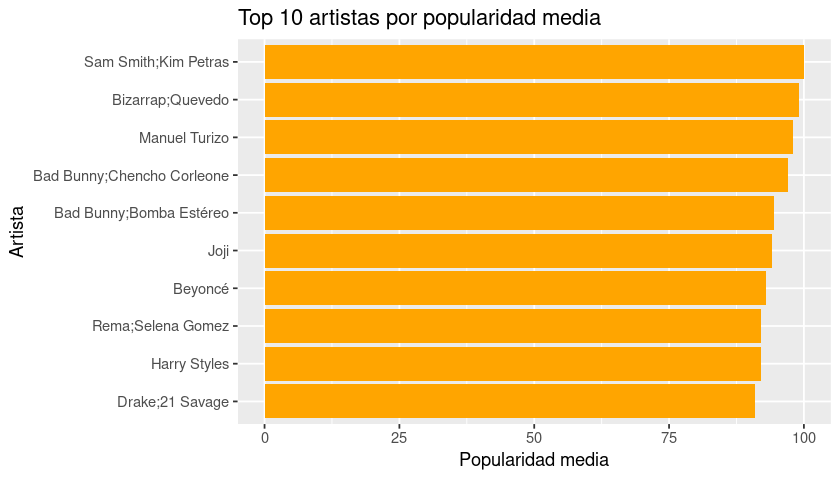

In [11]:
top_artistas <- spotify %>%
  group_by(artists) %>%
  summarise(canciones = n(), popularidad_media = mean(popularity, na.rm = TRUE)) %>%
  arrange(desc(popularidad_media)) %>% head(10)

ggplot(top_artistas, aes(x = reorder(artists, popularidad_media), y = popularidad_media)) +
  geom_col(fill = "orange") +
  coord_flip() +
  labs(title = "Top 10 artistas por popularidad media", x = "Artista", y = "Popularidad media")


## 9️⃣ Conclusiones

- La mayoría de canciones duran entre 2 y 4 minutos.
- La popularidad se concentra en valores medios-altos.
- Los géneros con más energía tienden a ser más populares.
- Existen correlaciones moderadas entre energía, danceability y valence.
